In [6]:
import pandas as pd
df_deliveries = pd.read_csv('deliveries.csv')
df_matches = pd.read_csv('matches.csv')
first_innings_deliveries = df_deliveries[df_deliveries['inning'] == 1]
innings_scores = first_innings_deliveries.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
innings_scores.rename(columns={'total_runs': 'first_innings_score'}, inplace=True)
merged_data = pd.merge(innings_scores, df_matches[['id', 'match_type']], left_on='match_id', right_on='id', how='left')
merged_data.drop(columns=['id'], inplace=True)


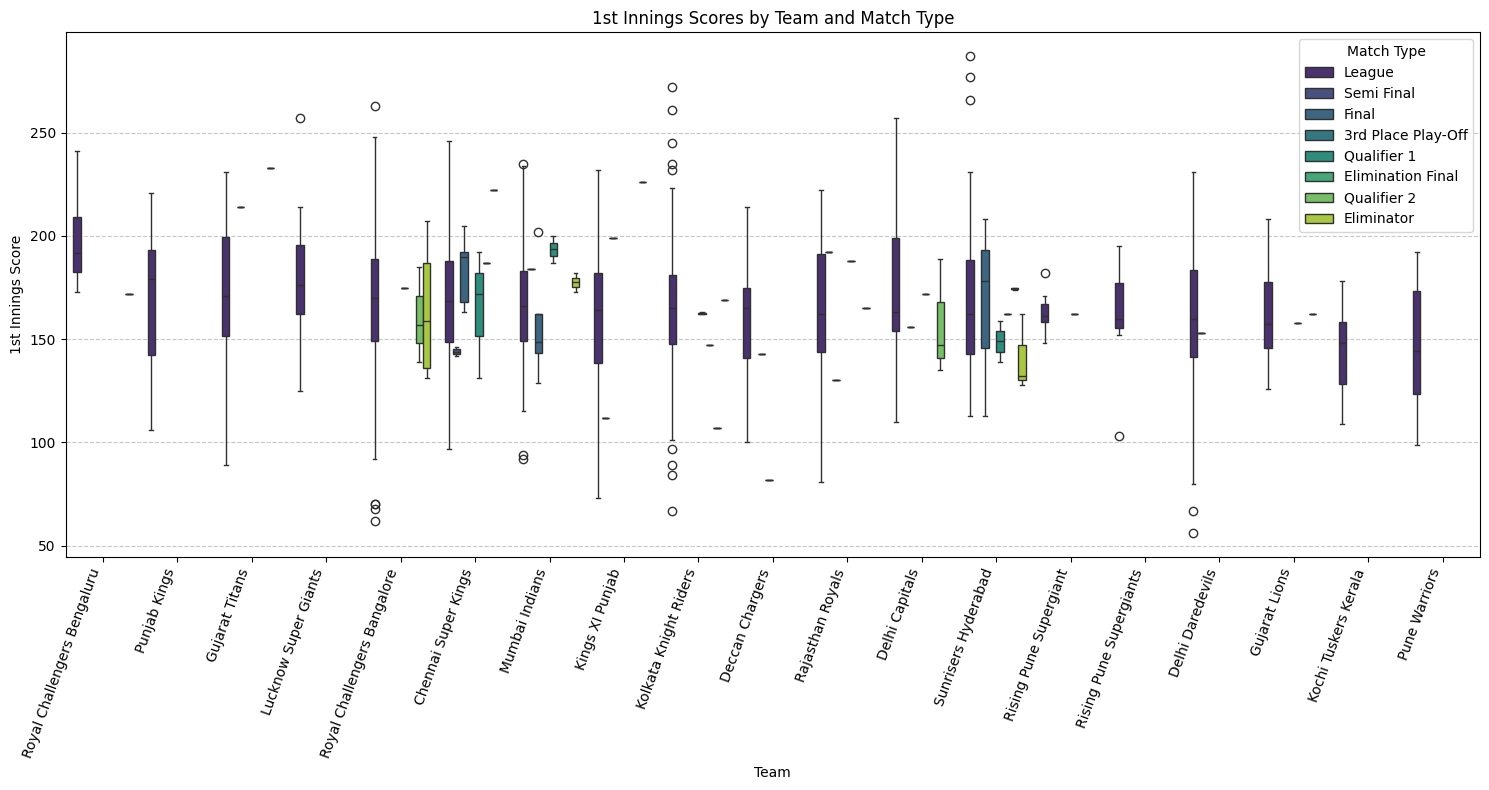

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
median_scores = merged_data.groupby('batting_team')['first_innings_score'].median().sort_values(ascending=False)
ordered_teams = median_scores.index
plt.figure(figsize=(15, 8)) 
sns.boxplot(x='batting_team', y='first_innings_score', hue='match_type', data=merged_data, order=ordered_teams, palette='viridis', width=0.8) 
plt.title('1st Innings Scores by Team and Match Type') 
plt.xlabel('Team')
plt.ylabel('1st Innings Score')
plt.xticks(rotation=70, ha='right') 
plt.legend(title='Match Type') 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout() 
plt.show()